# 01 — Data Preparation: Layer 2 (Macro Topic) Classifier

| | |
|---|---|
| **Project** | Public Pulse |
| **Pipeline stage** | Layer 2 — Macro Topic |
| **Notebook role** | Data preparation, language preprocessing, column scoping, and class imbalance mitigation |
| **Owner** | Thrithwaka |
| **Environment** | Google Colab, project files on Google Drive |
| **Upstream input** | `data/golden_sample/golden_sample_labeled.csv` |
| **Downstream consumers** | `02_training.ipynb`, `03_evaluation.ipynb` |
| **Random seed** | 42 |

## Purpose

Prepares Layer 2 training data with two corrections over an earlier version of this
notebook: (1) genuine Sinhala/Singlish/English-aware text preprocessing beyond just
choosing which text column to use, and (2) an explicit, auditable column-scoping step
that states up front exactly which columns belong to this layer and which are excluded
— rather than leaving that implicit in a feature-selection line deep in the notebook.

## How to Read This Notebook

No claim of 100% accuracy is made anywhere in this pipeline. Every preprocessing and
scoping decision is stated with its reasoning at the point it's made.

## 1. Google Colab Setup — Environment & Google Drive

Data preparation itself doesn't need a GPU — only the tokenizer compatibility check
(Section 10) touches `transformers`. We still apply the same dependency fix used in the
training notebooks for consistency across the whole Colab pipeline.

In [ ]:
!pip uninstall -y torchvision torchaudio -q
!pip install -q transformers==4.53.0 datasets accelerate sentencepiece "scikit-learn>=1.4"

print("Install complete.")
print("REQUIRED NEXT STEP: Runtime -> Restart session, then Runtime -> Run all from the top.")

Install complete.
REQUIRED NEXT STEP: Runtime -> Restart session, then Runtime -> Run all from the top.


**Stop here and restart the runtime now**, then **Runtime → Run all**.

In [ ]:
import transformers
print("transformers:", transformers.__version__)
assert transformers.__version__ == "4.53.0", "Did you Restart session after the install cell?"
print("Environment verified.")

transformers: 4.53.0
Environment verified.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/public-pulse-srilanka")

assert PROJECT_ROOT.exists(), f"Project folder not found at {PROJECT_ROOT} -- check the folder name."
print("Project root:", PROJECT_ROOT.resolve())

Mounted at /content/drive
Project root: /content/drive/MyDrive/public-pulse-srilanka


In [ ]:
golden_check = PROJECT_ROOT / "data" / "golden_sample" / "golden_sample_labeled.csv"
print("Golden sample exists:", golden_check.exists())
if not golden_check.exists():
    print("WARNING: golden_sample_labeled.csv not found -- check it was uploaded to Drive.")

Golden sample exists: True


## 2. Setup & Configuration

In [ ]:
import json
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

GOLDEN_SAMPLE_PATH = PROJECT_ROOT / "data" / "golden_sample" / "golden_sample_labeled.csv"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits" / "layer2"
MODEL_DIR = PROJECT_ROOT / "models" / "layer2_topic"
RESULTS_DIR = PROJECT_ROOT / "results" / "eda"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

UNRELIABLE_ANNOTATOR = "llm_groq_openai/gpt-oss-120b"
OVERSAMPLE_FLOOR = 400
OVERSAMPLE_MAX_MULTIPLIER = 3

print("Golden sample path:", GOLDEN_SAMPLE_PATH.resolve())

Golden sample path: /content/drive/MyDrive/public-pulse-srilanka/data/golden_sample/golden_sample_labeled.csv


## 3. Load the Golden Sample

In [ ]:
df = pd.read_csv(GOLDEN_SAMPLE_PATH)
print("Raw golden sample shape:", df.shape)

Raw golden sample shape: (10000, 28)


## 4. Data Cleaning

In [ ]:
before_n = len(df)
df_clean = df[df["annotator_id"] != UNRELIABLE_ANNOTATOR].copy()
print(f"Removed unreliable annotator batch: {before_n} -> {len(df_clean)} rows")

Removed unreliable annotator batch: 10000 -> 9290 rows


## 5. Column Scoping for Layer 2 — Explicit Allowlist

**This directly answers: "do I need Layer 1/3/4 columns when fine-tuning Layer 2?"**

- **Layer 1 (`layer1_utility_label`): needed only as a FILTER, not a feature.** Layer 2
  only applies to comments already judged `VALID` — this is how the taxonomy cascades.
  Once we've filtered to `VALID` rows, the column becomes constant (every remaining row
  says "VALID") and carries zero information, so it is dropped immediately after use.
- **Layer 3 (`layer3_subissue_label`): not needed at all.** Out of project scope
  entirely (see architecture decision log) — dropped, not merely unused.
- **Layer 4 (`layer4_stance_label`, `is_sarcastic`): not needed at all for this layer.**
  These belong to a separate, independent classification task with its own notebook.
  Including them here would risk future confusion about what this notebook's saved
  outputs actually contain, even though they're statistically harmless as unused columns.

We use an **allowlist** (explicitly state what's kept) rather than a denylist (try to
remember everything irrelevant to drop) — an allowlist fails safe: if a new column is
added to the raw dataset later, it's excluded by default unless someone deliberately adds
it here, rather than silently leaking in.

In [ ]:
# Step 1: apply the Layer 1 filter, then drop the now-constant column
valid_df = df_clean[df_clean["layer1_utility_label"] == "VALID"].copy()
print(f"Valid rows: {len(valid_df)} / {len(df_clean)}")

LAYER2_ALLOWED_COLUMNS = [
    "comment_id", "channel_name", "source_type", "text_raw",
    "language_detected", "message_length", "emoji_list",
    "layer2_topic_label",   # the target for this notebook
]

dropped_columns = set(valid_df.columns) - set(LAYER2_ALLOWED_COLUMNS)
print(f"\nColumns kept ({len(LAYER2_ALLOWED_COLUMNS)}): {LAYER2_ALLOWED_COLUMNS}")
print(f"Columns dropped ({len(dropped_columns)}), including layer1/3/4 targets: {sorted(dropped_columns)}")

valid_df = valid_df[LAYER2_ALLOWED_COLUMNS].copy()

assert "layer1_utility_label" not in valid_df.columns, "Layer 1 label should not remain as a feature"
assert "layer3_subissue_label" not in valid_df.columns, "Layer 3 must not appear in Layer 2's data"
assert "layer4_stance_label" not in valid_df.columns, "Layer 4 must not appear in Layer 2's data"
assert "is_sarcastic" not in valid_df.columns, "is_sarcastic belongs to Layer 4, not Layer 2"
print("\nColumn scoping verified: only Layer-2-relevant columns remain.")

Valid rows: 7686 / 9290

Columns kept (8): ['comment_id', 'channel_name', 'source_type', 'text_raw', 'language_detected', 'message_length', 'emoji_list', 'layer2_topic_label']
Columns dropped (20), including layer1/3/4 targets: ['annotation_notes', 'annotator_id', 'author_broadcast_msg_count', 'author_hash', 'broadcast_id', 'duplicate_group_id', 'is_duplicate_text', 'is_flooding_spam', 'is_member', 'is_reply', 'is_sarcastic', 'is_super_chat', 'layer1_utility_label', 'layer3_subissue_label', 'layer4_stance_label', 'length_bucket', 'parent_comment_id', 'published_at', 'strata_key', 'text_normalized']

Column scoping verified: only Layer-2-relevant columns remain.


### 5.1 Confirm `NULL` Has Zero Examples

In [ ]:
null_count = valid_df["layer2_topic_label"].isna().sum()
print(f"Rows with blank/NULL layer2_topic_label: {null_count} / {len(valid_df)}")
if null_count == 0:
    print("FINDING: Zero NULL examples -- excluded from the trainable label set below.")

Rows with blank/NULL layer2_topic_label: 0 / 7686
FINDING: Zero NULL examples -- excluded from the trainable label set below.


## 6. Language-Aware Text Preprocessing (Sinhala / Singlish / English)

Three text variants now exist for comparison:
- `text_raw` — completely unmodified
- `text_normalized` — the dataset's own aggressive normalization (lowercased, punctuation stripped)
- `text_clean` *(built here)* — safe, lossless cleanup only

**What `text_clean` does and why each step is safe for all three languages:**

1. **Unicode NFC normalization** — Sinhala script can represent the same visible
   character through different sequences of combining marks. Without normalizing to a
   single canonical form, the tokenizer can treat two visually identical comments as
   different token sequences, silently fragmenting the vocabulary the model has to learn
   from. This is the single most important preprocessing step specific to Sinhala that
   was missing before.
2. **Zero-width character removal** — invisible Unicode characters (zero-width space,
   joiner, non-joiner, BOM) are a common web-scraping artifact and carry no linguistic
   signal in Sinhala, Singlish, or English.
3. **URL replacement with a `[URL]` placeholder** — preserves the signal "a link was
   shared" without a long URL consuming the token budget or introducing noise.
4. **Whitespace collapsing** — multiple spaces/tabs/newlines within a comment are
   collapsed to one space; leading/trailing whitespace trimmed.

**What `text_clean` deliberately does NOT do**, carried forward from the earlier
`text_raw` vs. `text_normalized` decision: no lowercasing, no punctuation stripping, no
repeated-character collapsing, no stemming. Punctuation, casing, and emphasis patterns
are plausibly informative signal for a pretrained subword-tokenizer transformer, and
removing them is a classical-NLP habit that doesn't transfer well to fine-tuning models
like XLM-RoBERTa.

**Engineering note:** this function is defined inline here for notebook self-containment.
It should be refactored into `src/public_pulse/preprocessing/text_cleaning.py` and
imported identically by every layer's notebook, so the exact same cleaning logic is
guaranteed to run at both training and inference time.

In [ ]:
ZERO_WIDTH_PATTERN = re.compile(r"[\u200b\u200c\u200d\ufeff]")
WHITESPACE_PATTERN = re.compile(r"\s+")
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFC", text)
    text = ZERO_WIDTH_PATTERN.sub("", text)
    text = URL_PATTERN.sub("[URL]", text)
    text = WHITESPACE_PATTERN.sub(" ", text).strip()
    return text

valid_df["text_clean"] = valid_df["text_raw"].apply(clean_text)

# Show where it actually changed something
changed = valid_df[valid_df["text_raw"] != valid_df["text_clean"]]
print(f"Rows changed by cleaning: {len(changed)} / {len(valid_df)} ({len(changed)/len(valid_df)*100:.1f}%)")
print()
for _, r in changed.sample(min(4, len(changed)), random_state=RANDOM_STATE).iterrows():
    print(f"  RAW:   {r['text_raw'][:70]!r}")
    print(f"  CLEAN: {r['text_clean'][:70]!r}")
    print()

Rows changed by cleaning: 2128 / 7686 (27.7%)

  RAW:   'ඇය කියන්නේ  සෑම රජයේ ආයතනයකම මගේ පොටෝ\r\nඑක ගහන්න එපා😮 මම එතන හිතුවා'
  CLEAN: 'ඇය කියන්නේ සෑම රජයේ ආයතනයකම මගේ පොටෝ එක ගහන්න එපා😮 මම එතන හිතුවා'

  RAW:   ', ජංගි අරගල කරලා IMF ගෙනාවා, රනිල් AKD ජනපති කලා, ආර්ථිකය, ජාතික ආරක්ෂ'
  CLEAN: ', ජංගි අරගල කරලා IMF ගෙනාවා, රනිල් AKD ජනපති කලා, ආර්ථිකය, ජාතික ආරක්ෂ'

  RAW:   'Dama ඝාතක sataka නිකායේ  saga සමුළුව 😂😂😂😂😂'
  CLEAN: 'Dama ඝාතක sataka නිකායේ saga සමුළුව 😂😂😂😂😂'

  RAW:   'මෙහෙම කියන්න ඔයත් පළාත් සබා අපේක්ෂකයෙක් වෙන්න ඕන . උන්ට ඇර මේ රටේ කාටව'
  CLEAN: 'මෙහෙම කියන්න ඔයත් පළාත් සබා අපේක්ෂකයෙක් වෙන්න ඕන . උන්ට ඇර මේ රටේ කාටව'



**Decision: `text_clean` is the model input for this layer**, superseding the plain
`text_raw` choice used in an earlier version of this notebook. `text_raw` is retained in
the saved splits for human-readability during manual review, but the model only ever
sees `text_clean`.

## 7. Feature Engineering — Script Composition Diagnostics

As established previously: these are diagnostic features for EDA, not model inputs.
XLM-RoBERTa learns directly from tokenized `text_clean`.

In [ ]:
SINHALA_RANGE = re.compile(r"[\u0D80-\u0DFF]")
LATIN_RANGE = re.compile(r"[A-Za-z]")

def script_composition(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0, 0.0, False
    sinhala_chars = len(SINHALA_RANGE.findall(text))
    latin_chars = len(LATIN_RANGE.findall(text))
    total = sinhala_chars + latin_chars
    if total == 0:
        return 0.0, 0.0, False
    s_ratio = sinhala_chars / total
    l_ratio = latin_chars / total
    return round(s_ratio, 3), round(l_ratio, 3), (s_ratio > 0.1 and l_ratio > 0.1)

feats = valid_df["text_clean"].apply(script_composition)
valid_df["sinhala_char_ratio"] = feats.apply(lambda x: x[0])
valid_df["latin_char_ratio"] = feats.apply(lambda x: x[1])
valid_df["is_code_switched"] = feats.apply(lambda x: x[2])
valid_df["emoji_count"] = valid_df["emoji_list"].apply(lambda x: 0 if pd.isna(x) else len(str(x).split(",")))

print("Code-switching rate:", f"{valid_df['is_code_switched'].mean()*100:.1f}%")

Code-switching rate: 7.2%


layer2_topic_label
TOPIC_SERV     14.7
TOPIC_MEDIA     9.2
TOPIC_GOV       7.4
TOPIC_FOR       5.6
TOPIC_LAW       3.3
TOPIC_ECON      2.6
Name: is_code_switched, dtype: float64


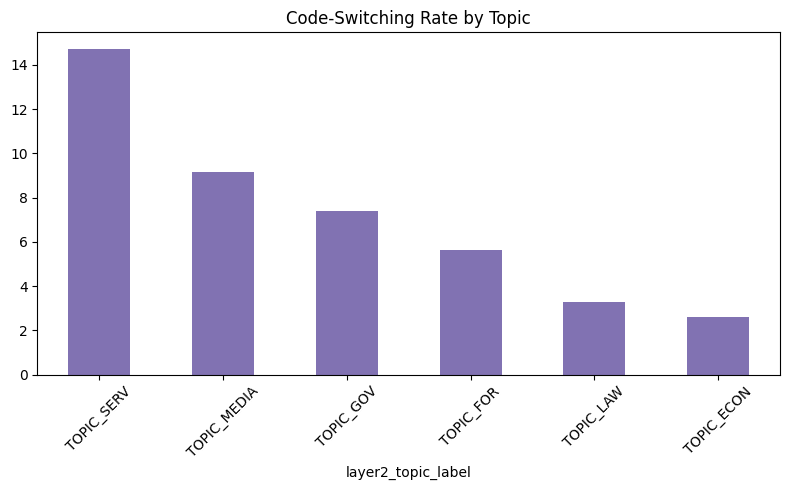

In [ ]:
codeswitch_by_topic = valid_df.groupby("layer2_topic_label")["is_code_switched"].mean().sort_values(ascending=False) * 100
print(codeswitch_by_topic.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
codeswitch_by_topic.plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("Code-Switching Rate by Topic")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "layer2_codeswitch_by_topic.png", dpi=150)
plt.show()

## 8. Layer 2 Target Variable Analysis

In [ ]:
l2_counts = valid_df["layer2_topic_label"].value_counts()
print(pd.DataFrame({"count": l2_counts, "percent": (l2_counts/len(valid_df)*100).round(1)}))

                    count  percent
layer2_topic_label                
TOPIC_GOV            6333     82.4
TOPIC_LAW             457      5.9
TOPIC_MEDIA           382      5.0
TOPIC_FOR             266      3.5
TOPIC_ECON            153      2.0
TOPIC_SERV             95      1.2


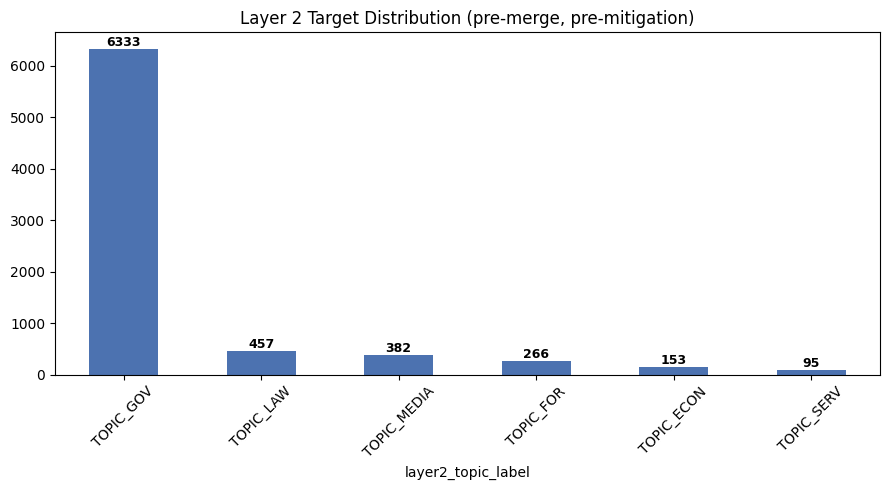

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
l2_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Layer 2 Target Distribution (pre-merge, pre-mitigation)")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(l2_counts):
    ax.text(i, v + 60, str(v), ha="center", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "layer2_target_distribution_raw.png", dpi=150)
plt.show()

## 9. Merge Rare Classes — Documented Scope Decision

`TOPIC_ECON` (153) and `TOPIC_SERV` (95) both fail the data-sufficiency floor even after
oversampling. Merged into `TOPIC_ECON_SERV`, per the project's deadline- and
dataset-constrained scope decision. Original labels preserved for traceability.

In [ ]:
MERGE_MAP = {"TOPIC_ECON": "TOPIC_ECON_SERV", "TOPIC_SERV": "TOPIC_ECON_SERV"}

valid_df["layer2_topic_label_original"] = valid_df["layer2_topic_label"]
valid_df["layer2_topic_label"] = valid_df["layer2_topic_label"].replace(MERGE_MAP)

print(valid_df["layer2_topic_label"].value_counts())
print(f"\nClasses: {valid_df['layer2_topic_label'].nunique()}")

layer2_topic_label
TOPIC_GOV          6333
TOPIC_LAW           457
TOPIC_MEDIA         382
TOPIC_FOR           266
TOPIC_ECON_SERV     248
Name: count, dtype: int64

Classes: 5


## 10. Class Balance Assessment

In [ ]:
FLOOR, TARGET = 400, 800
l2_counts_merged = valid_df["layer2_topic_label"].value_counts()
assessment = pd.DataFrame({"count": l2_counts_merged})
assessment["meets_floor"] = assessment["count"] >= FLOOR
assessment["meets_target"] = assessment["count"] >= TARGET
print(assessment)

                    count  meets_floor  meets_target
layer2_topic_label                                  
TOPIC_GOV            6333         True          True
TOPIC_LAW             457         True         False
TOPIC_MEDIA           382        False         False
TOPIC_FOR             266        False         False
TOPIC_ECON_SERV       248        False         False


## 11. Stratified Train / Validation / Test Split

Split first, mitigate imbalance second — non-negotiable ordering to prevent oversampled
duplicates leaking across splits.

In [ ]:
feature_cols = ["comment_id", "text_raw", "text_clean", "channel_name", "source_type",
                "language_detected", "sinhala_char_ratio", "latin_char_ratio",
                "is_code_switched", "emoji_count"]

X = valid_df[feature_cols]
y = valid_df["layer2_topic_label"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

train_df = X_train.copy(); train_df["layer2_topic_label"] = y_train
val_df = X_val.copy(); val_df["layer2_topic_label"] = y_val
test_df = X_test.copy(); test_df["layer2_topic_label"] = y_test

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print(train_df["layer2_topic_label"].value_counts())

Train: 5380  Val: 1153  Test: 1153
layer2_topic_label
TOPIC_GOV          4433
TOPIC_LAW           320
TOPIC_MEDIA         267
TOPIC_FOR           186
TOPIC_ECON_SERV     174
Name: count, dtype: int64


## 12. Class Imbalance Mitigation

In [ ]:
def compute_oversample_target(n, floor, mult):
    return n if n >= floor else min(floor, n * mult)

train_counts = train_df["layer2_topic_label"].value_counts()
plan = pd.DataFrame({"original_count": train_counts})
plan["target_count"] = plan["original_count"].apply(lambda n: compute_oversample_target(n, OVERSAMPLE_FLOOR, OVERSAMPLE_MAX_MULTIPLIER))
print(plan)

                    original_count  target_count
layer2_topic_label                              
TOPIC_GOV                     4433          4433
TOPIC_LAW                      320           400
TOPIC_MEDIA                    267           400
TOPIC_FOR                      186           400
TOPIC_ECON_SERV                174           400


In [ ]:
parts = [train_df]
for topic, row in plan.iterrows():
    extra_needed = int(row["target_count"] - row["original_count"])
    if extra_needed > 0:
        pool = train_df[train_df["layer2_topic_label"] == topic]
        parts.append(pool.sample(n=extra_needed, replace=True, random_state=RANDOM_STATE))

train_oversampled_df = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print("Before:", len(train_df), " After:", len(train_oversampled_df))
print(train_oversampled_df["layer2_topic_label"].value_counts())

Before: 5380  After: 6033
layer2_topic_label
TOPIC_GOV          4433
TOPIC_LAW           400
TOPIC_FOR           400
TOPIC_MEDIA         400
TOPIC_ECON_SERV     400
Name: count, dtype: int64


In [ ]:
LAYER2_LABELS = sorted(train_oversampled_df["layer2_topic_label"].unique())
weights_arr = compute_class_weight(class_weight="balanced", classes=np.array(LAYER2_LABELS), y=train_oversampled_df["layer2_topic_label"].values)
class_weights_dict = dict(zip(LAYER2_LABELS, weights_arr.round(4)))
print(class_weights_dict)

with open(MODEL_DIR / "class_weights.json", "w") as f:
    json.dump(class_weights_dict, f, indent=2)

{'TOPIC_ECON_SERV': np.float64(3.0165), 'TOPIC_FOR': np.float64(3.0165), 'TOPIC_GOV': np.float64(0.2722), 'TOPIC_LAW': np.float64(3.0165), 'TOPIC_MEDIA': np.float64(3.0165)}


## 13. Data Quality Validation

In [ ]:
errors = []
for name, sdf in [("train", train_oversampled_df), ("val", val_df), ("test", test_df)]:
    if sdf["layer2_topic_label"].isna().any():
        errors.append(f"{name}: missing labels")
    invalid = set(sdf["layer2_topic_label"].unique()) - set(LAYER2_LABELS)
    if invalid:
        errors.append(f"{name}: unexpected labels {invalid}")
    for leaked_col in ["layer1_utility_label", "layer3_subissue_label", "layer4_stance_label", "is_sarcastic"]:
        if leaked_col in sdf.columns:
            errors.append(f"{name}: {leaked_col} leaked into Layer 2 data")

val_test_ids = set(val_df["comment_id"]) | set(test_df["comment_id"])
if val_test_ids & set(train_oversampled_df["comment_id"]):
    errors.append("LEAKAGE between train and val/test")

if errors:
    for e in errors: print("FAIL:", e)
    raise ValueError("Data quality checks failed.")
print("All checks passed: labels valid, no cross-layer column leakage, no train/val/test leakage.")

All checks passed: labels valid, no cross-layer column leakage, no train/val/test leakage.


## 14. Save Splits

In [ ]:
train_oversampled_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test.csv", index=False)
print("Saved train/val/test to", SPLITS_DIR.resolve())

Saved train/val/test to /content/drive/MyDrive/public-pulse-srilanka/data/splits/layer2


## 15. Tokenizer Compatibility Check (on `text_clean`)

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
MAX_SEQ_LENGTH = 256

token_lengths = train_oversampled_df["text_clean"].apply(lambda t: len(tokenizer.tokenize(str(t))))
pct_truncated = (token_lengths > MAX_SEQ_LENGTH).mean() * 100
print(f"% exceeding max_seq_length={MAX_SEQ_LENGTH}: {pct_truncated:.2f}%")
print(token_lengths.describe())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (855 > 512). Running this sequence through the model will result in indexing errors


% exceeding max_seq_length=256: 0.73%
count    6033.000000
mean       32.850986
std        54.809453
min         1.000000
25%         9.000000
50%        19.000000
75%        37.000000
max      1137.000000
Name: text_clean, dtype: float64


## 16. Notebook Summary

### What changed from the earlier version
1. **Added genuine language-aware preprocessing** (`text_clean`): Unicode NFC
   normalization (critical for Sinhala), zero-width character removal, URL
   placeholder substitution, whitespace collapsing — all lossless, none remove
   punctuation/casing signal.
2. **Added explicit column scoping** (Section 5): an allowlist stating exactly which
   columns belong to Layer 2, with hard assertions confirming Layer 1/3/4 columns are
   absent — not just implicitly excluded via a later feature-selection line.

### Outputs
| File | Contents |
|---|---|
| `data/splits/layer2/{train,val,test}.csv` | Contains both `text_raw` (reference) and `text_clean` (model input) |
| `models/layer2_topic/class_weights.json` | Post-oversampling class weights |
| `results/eda/layer2_*.png` | Diagnostic plots |

## 17. Handover Notes — For `02_training.ipynb`

**Model input column is now `text_clean`, not `text_raw`.** Update the tokenization
step in `02_training.ipynb` accordingly: `examples["text_clean"]`, not
`examples["text_raw"]`.

**Label set:** 5 classes (`TOPIC_ECON_SERV` merged). `num_labels=5`.

**Class weights:** `models/layer2_topic/class_weights.json`, already correctly
post-oversampling — load and use directly.

**Column contract:** the saved splits contain only Layer-2-relevant columns plus
`text_raw`/`text_clean` for reference — no Layer 1/3/4 columns present, verified by
Section 13's assertions.